In [1]:
from transformers import pipeline
import warnings as wrn
wrn.filterwarnings('ignore', category = DeprecationWarning)
wrn.filterwarnings('ignore', category = FutureWarning)
wrn.filterwarnings('ignore', category = UserWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from PIL import Image
import numpy as np

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [7]:
classifier = pipeline("text-classification", model="distilbert-base-uncased-finetuned-sst-2-english")

Device set to use cuda:0


In [9]:
df = pd.read_csv('Beginner_Reviews_dataset.csv')
df

,Unnamed: 0,sentence,label
0,0,Wow... Loved this place.,1
1,1,Crust is not good.,0
2,2,Not tasty and the texture was just nasty.,0
3,3,Stopped by during the late May bank holiday of...,1
4,4,The selection on the menu was great and so wer...,1
...,...,...,...
995,995,I think food should have flavor and texture an...,0
996,996,Appetite instantly gone.,0
997,997,Overall I was not impressed and would not go b...,0
998,998,"The whole experience was underwhelming, and I ...",0


In [11]:
X = df[['sentence']]
y = df[['label']]

In [21]:
X.loc[0]

sentence    Wow... Loved this place.
Name: 0, dtype: object

In [23]:
results = classifier(X.loc[0].to_string())

In [25]:
results

[{'label': 'POSITIVE', 'score': 0.9998630285263062}]

In [31]:
results[0]['label']

'POSITIVE'

In [47]:
int(y.loc[0])

1

In [49]:
tp = 0
tn = 0
fp = 0
fn = 0
for i in range(1000):
    results = classifier(X.loc[i].to_string())
    real = int(y.loc[i])
    if results[0]['label'] == 'POSITIVE':
        if real == 1:
            tp = tp + 1
        if real == 0:
            fp = fp + 1
    if results[0]['label'] == 'NEGATIVE':
        if real == 1:
            fn = fn + 1
        if real == 0:
            tn = tn + 1
print('Accuracy:', (tp+tn)/(tp+tn+fp+fn))
print('Precision:', tp/(tp+fp))
print('Recall:', tp/(tp+fn))
print('F1:', 2*tp/(2*tp + fp + fn))

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Accuracy: 0.816
Precision: 0.9388888888888889
Recall: 0.676
F1: 0.786046511627907


In [51]:
model = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment", device=0)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


In [63]:
results = model(X.loc[3].to_string())
results

[{'label': 'LABEL_1', 'score': 0.790799617767334}]

In [71]:
tp = 0
tn = 0
fp = 0
fn = 0
for i in range(1000):
    results = model(X.loc[i].to_string())
    real = int(y.loc[i])
    if results[0]['label'] == 'LABEL_2':
        if real == 1:
            tp = tp + 1
        if real == 0:
            fp = fp + 1
    if results[0]['label'] == 'LABEL_1':
        if real == 1:
            tp = tp + 1
        if real == 0:
            fp = fp + 1
    if results[0]['label'] == 'LABEL_0':
        if real == 1:
            fn = fn + 1
        if real == 0:
            tn = tn + 1
print(tp, tn, fp, fn)
print('Accuracy:', (tp+tn)/(tp+tn+fp+fn))
print('Precision:', tp/(tp+fp))
print('Recall:', tp/(tp+fn))
print('F1:', 2*tp/(2*tp + fp + fn))

489 331 169 11
Accuracy: 0.82
Precision: 0.743161094224924
Recall: 0.978
F1: 0.844559585492228


In [73]:
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4").to("cuda")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [75]:
prompt = (
    "an anime-style cozy cyberpunk workplace of hacker"
)
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

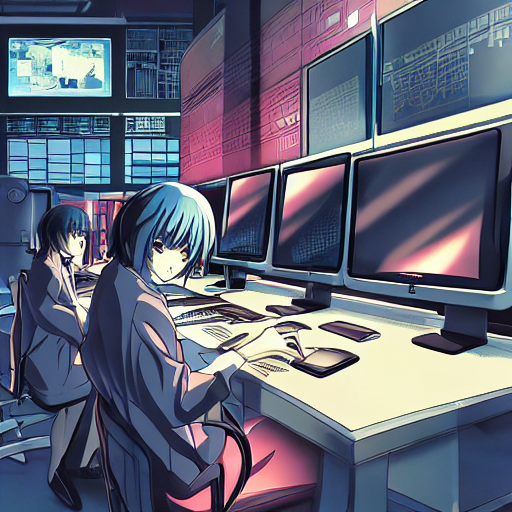

In [77]:
image